In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [9]:
df = pd.read_csv("player_valuation_dataset.csv")

print(df.shape)
df.head()

C:\Users\amalb\AppData\Local\Temp\ipykernel_19760\689054395.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("player_valuation_dataset.csv")


(33557, 41)


,player_id,player_name,date_of_birth,height,citizenship,is_eu,position,main_position,foot,current_club_id,...,goal_contributions,current_market_value,value_change_pct,total_days_injured,total_injuries,injury_proneness,club_id,competition_name,club_division,age
0,100001,Carlos Auzqui (100001),1991-03-16,180.0,Argentina,False,Attack - Right Winger,Attack,right,14554,...,79.0,200000.0,100.00,0.0,0.0,0.00,14554.0,Torneo Clausura,Torneo Clausura,34
1,1000274,Brian Romero (1000274),2006-05-11,0.0,United States Mexico,False,Attack - Right Winger,Attack,NaN,78435,...,6.0,150000.0,0.00,0.0,0.0,0.00,78435.0,Major League Soccer,Major League Soccer,19
2,1000273,Nimfasha Berchimas (1000273),2008-02-22,172.0,United States Burundi,False,Attack - Left Winger,Attack,right,78435,...,12.0,400000.0,-20.00,206.0,1.0,0.33,78435.0,Major League Soccer,Major League Soccer,18
3,1000135,Joselu Pérez (1000135),2004-03-12,183.0,Spain,True,Attack - Centre-Forward,Attack,right,8510,...,8.0,100000.0,300.00,0.0,0.0,0.00,NaN,NaN,NaN,21
4,1000284,Jed Drew (1000284),2003-08-29,176.0,Australia,False,Attack - Right Winger,Attack,right,4467,...,39.0,550000.0,266.67,40.0,3.0,1.00,4467.0,Bundesliga,Bundesliga,22


In [10]:
numeric_df = df.select_dtypes(include=[np.number]).copy()

print("Number of numeric features:", numeric_df.shape[1])

Number of numeric features: 21


In [11]:
cols_to_exclude = [
    'player_id',
    'current_club_id',
    'club_id',
    'current_market_value'  # target-like variable
]

X = numeric_df.drop(columns=[col for col in cols_to_exclude if col in numeric_df.columns], errors='ignore')

In [12]:
# remove constant columns
X = X.loc[:, X.nunique() > 1]

# fill missing values
X = X.fillna(0)

In [15]:
# Keep only true numeric columns
X = X.select_dtypes(include=[np.number]).copy()

# Replace inf values with NaN, then fill
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# check data types
print(X.dtypes.value_counts())
print(X.shape)

float64    15
int64       1
Name: count, dtype: int64
(33557, 16)


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_summary = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Explained Variance': explained_variance,
    'Cumulative Variance': cumulative_variance
})

pca_summary.head(10)

,PC,Explained Variance,Cumulative Variance
0,PC1,0.347256,0.347256
1,PC2,0.152329,0.499585
2,PC3,0.104948,0.604533
3,PC4,0.063601,0.668134
4,PC5,0.061562,0.729697
5,PC6,0.059786,0.789483
6,PC7,0.055634,0.845117
7,PC8,0.042704,0.887821
8,PC9,0.035238,0.923059
9,PC10,0.023946,0.947004


In [25]:
# FIND NUMBER OF COMPONENTS FOR 80% AND 90%

n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Number of components explaining at least 80% variance:", n_components_80)
print("Number of components explaining at least 90% variance:", n_components_90)

Number of components explaining at least 80% variance: 7
Number of components explaining at least 90% variance: 9


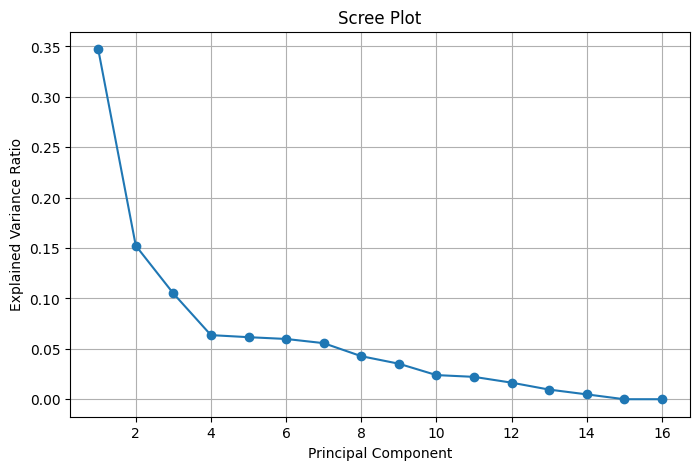

In [26]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()


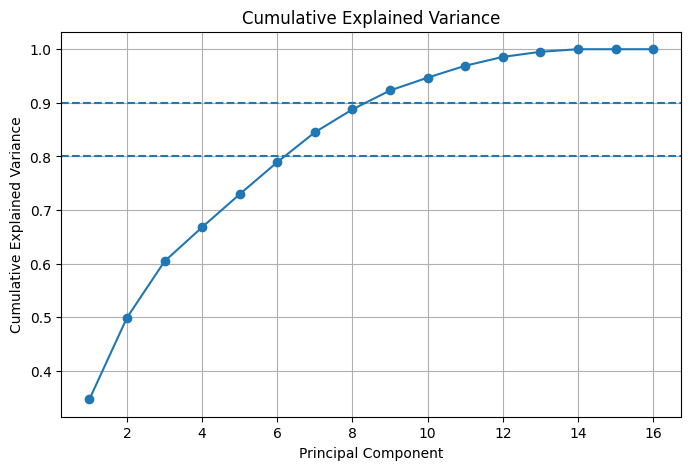

In [27]:
#CUMULATIVE EXPLAINED VARIANCE PLOT
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.80, linestyle='--')
plt.axhline(y=0.90, linestyle='--')
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()


In [20]:
pca_final = PCA(n_components=0.90)  # keep 90% variance
X_reduced = pca_final.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)
print("Number of components kept:", pca_final.n_components_)

Original shape: (33557, 16)
Reduced shape: (33557, 9)
Number of components kept: 9


In [21]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_final.n_components_)],
    index=X.columns
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
height,0.111637,-0.110639,-0.029968,0.426349,0.224188,-0.507913,0.670304,-0.043349,-0.159613
on_loan_from_club_id,-0.044127,0.049644,0.015702,-0.361290,0.919250,-0.075171,-0.114635,0.020977,-0.002555
matches,0.376151,-0.135193,-0.225192,0.045063,0.024576,-0.010435,-0.134122,0.046581,0.029906
goals,0.311003,0.347380,-0.123474,0.017297,-0.000478,-0.037696,-0.058060,-0.349462,-0.040997
assists,0.332056,0.217454,-0.088410,0.038636,0.002803,0.017511,-0.166538,0.175390,-0.487638


In [22]:
loadings['PC1'].abs().sort_values(ascending=False).head(10)

matches               0.376151
goal_contributions    0.342586
assists               0.332056
goals                 0.311003
total_injuries        0.308970
injury_proneness      0.308968
age                   0.305713
yellow_cards          0.296384
total_days_injured    0.223472
minutes_played        0.184837
Name: PC1, dtype: float64

In [23]:
# Show how much variance each PC explains
print(pca_summary.head(10))

# Key interpretation values
total_variance_80 = np.argmax(cumulative_variance >= 0.80) + 1
total_variance_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Number of components to explain 80% variance: {total_variance_80}")
print(f"Number of components to explain 90% variance: {total_variance_90}")

     PC  Explained Variance  Cumulative Variance
0   PC1            0.347256             0.347256
1   PC2            0.152329             0.499585
2   PC3            0.104948             0.604533
3   PC4            0.063601             0.668134
4   PC5            0.061562             0.729697
5   PC6            0.059786             0.789483
6   PC7            0.055634             0.845117
7   PC8            0.042704             0.887821
8   PC9            0.035238             0.923059
9  PC10            0.023946             0.947004
Number of components to explain 80% variance: 7
Number of components to explain 90% variance: 9


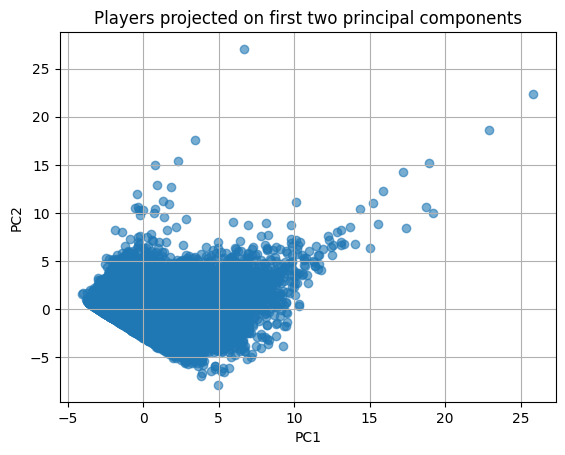

In [24]:
# 2D PCA projection
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Players projected on first two principal components")
plt.grid()
plt.show()

In [30]:
# PCA was used to reduce the dimensionality of the player valuation dataset while preserving as much information as possible. Since the variables were measured on different scales, the data was standardized before applying PCA. The results showed that the first principal components explained a large proportion of the total variance, meaning that the original dataset can be summarized with fewer dimensions. The scree plot and cumulative explained variance confirmed that only a limited number of components were needed to retain most of the information. By examining the loadings, it was also possible to identify which original variables contributed most strongly to the first components. Overall, PCA simplified the structure of the dataset and created a reduced representation that can be useful for later modeling or clustering.